In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np

from Utils.load_files import load_binary
from Utils.json_tools import read_formatted_json
# from Utils.recording import detect_exposure_time, interp_replace
from Utils.recording import detect_exposure_time
from Utils.kilosort_utils import gen_adc_spike_time
from pathlib import Path
import matplotlib
# Restart the kernel to revert changes to matplotlib settings
# matplotlib.use('TkAgg')  # Use TkAgg backend for interactive plotting

import matplotlib.pyplot as plt
from Utils.Sessions import Session
from Utils.ttl_utils import intervals_ranges_index_to_frames, fill_short_gaps
from scipy.io import loadmat

from Utils.recording import interp_replace
from Utils.session_edits import check_session_edits



32


In [3]:
"""
Change all the variables below to match recording.
"""

is_overwrite_parameters: bool = True
base_dir = r"/mnt/senzailab/Kai/#Recording/m18"

# base_dir = "data"
date: str | int = "260812"

num_of_rec: int = 2

headplate_name: str = 'hp4'

subfolder_filler = f"{date}_{num_of_rec}"

probe_list: list[str] = ["A", ]

sessionEdit = check_session_edits(
    f"{base_dir}/session_slices.sqlite3",
    date,
    num_of_rec,
)

base_dir = f"{base_dir}/{date}/{subfolder_filler}"

# These are 0 indexed channel numbers
camera_input_channel: int = 1
analogue_input_channel: int = 3

is_convert_to_zero: bool = False
time_interval: bool = False
is_signal_inverted: bool = True

detect_ADC_DI_threshold, fill_short_gaps_1, fill_short_gaps_2 = 15000, 10, 1000
detect_on_list_threshold: float = 0.5

parameters_file = Path(f'{base_dir}/data/parameters.json')

"""------------------------------------------------------------------"""
oebin_file_dir = next((Path(base_dir) / date).glob("*/experiment1/recording1/structure.oebin"))

session = Session(oebin_file_dir)
session_info = session.get_session_info()

base_data_dir = session_info['base_path']
record_nodes: str = session_info['record_nodes']
recording_name: str = session_info['recording_name']
experiment_id: str = session_info['experiment_id']

path_between = f'/{record_nodes}/{experiment_id}/'
continuous_folder = base_data_dir + path_between + recording_name + '/continuous/'
#
for probe in probe_list:
    print("==============================")
    print(f"Generating probe{probe} ADC spike time...")
    if (_ := gen_adc_spike_time(session_info=session_info,
                                probe=probe,
                                base_dir=base_dir,
                                num_of_rec=num_of_rec,
                                save_file_name="adc_spike_time",
                                is_convert_to_zero=is_convert_to_zero))[0]:
        print(f"probe{probe}_continuous_timestamp saved to {_[1]}")

print("==============================")
print("Loading ADC npy data...")
deleteStartIndex = None
deleteEndIndex = None
deleteFrames, interp_start, interp_end, frames_between = None, None, None, None

ADC_name: str = session_info['continuous_ADC_folder']
analogue_total_input_channel_number: int = session_info['ADC_input_channel']
ADC_sampling_rate: float = session_info['ADC_sample_rate']
ADC_datafile = continuous_folder + ADC_name + '/continuous.dat'

photodiode_data = load_binary(ADC_datafile, analogue_total_input_channel_number, analogue_input_channel)

ADC_continuous_time_stamp_file = f'{continuous_folder}/{ADC_name}/timestamps.npy'
ADC_continuous_time_stamp_data_raw = np.load(ADC_continuous_time_stamp_file, mmap_mode='r')

if is_convert_to_zero:
    ADC_continuous_time_stamp_data = (ADC_continuous_time_stamp_data_raw - ADC_continuous_time_stamp_data_raw[0])
else:
    ADC_continuous_time_stamp_data = ADC_continuous_time_stamp_data_raw

assert len(ADC_continuous_time_stamp_data) == len(
    photodiode_data), f"Length mismatch: {len(ADC_continuous_time_stamp_data)} vs {len(photodiode_data)}"

print(f"ADC_continuous_time_stamp_data: {ADC_continuous_time_stamp_data.shape}")
ADC_duration = len(photodiode_data) / ADC_sampling_rate
print(f"ADC duration: {ADC_duration} ")

edge_threshold = 1000
max_internal_gap = 300

raw_active = photodiode_data > edge_threshold

ADC_DI_data_noGap = fill_short_gaps(
    raw_active,
    min_gap=max_internal_gap,
)

# ADC_DI_data_noGap = fill_short_gaps(~(fill_short_gaps(photodiode_data < 15000, min_gap=10)), min_gap=1000)

assert len(ADC_continuous_time_stamp_data) == len(
    ADC_DI_data_noGap), f"Length mismatch: {len(ADC_continuous_time_stamp_data)} vs {len(ADC_DI_data_noGap)}"

on_list_detected = detect_exposure_time(
    ADC_continuous_time_stamp_data,
    ADC_DI_data_noGap,
    threshold=detect_on_list_threshold,
    time_interval=False,
    is_inverted=is_signal_inverted,
    detection_target_label="on_list",
).ravel()

on_list_detected[-1] = (on_list_detected[-1] - 1) if on_list_detected[-1] == len(ADC_continuous_time_stamp_data) else \
    on_list_detected[-1]

on_list_time = ADC_continuous_time_stamp_data[on_list_detected]

"""# 260714_3
# sessionEdit.deleteByFrame([14483, 14484])

# 260716_3
# sessionEdit.deleteByFrame([10120, 10121])

# 260716_4
# sessionEdit.interp(1621, 1623, 13)"""

(saved, stored_data), edited_target = sessionEdit.getSessionInfo(
    target=on_list_time
)

# deleteFrames: list[int] = [6048, 6049]

deleteStartIndex = 0
deleteEndIndex = -47

# (start, end, frames_between)
# interp_start, interp_end, frames_between = 2255, 2258, 13

if saved:
    on_list_time = edited_target
    print(f"Stored edits applied: {stored_data}")
else:
    if deleteFrames:
        on_list_time = np.delete(on_list_time, deleteFrames,)

    on_list_time = on_list_time[deleteStartIndex:deleteEndIndex]

    if interp_start:
        on_list_time = interp_replace(
                on_list_time,
                interp_start,
                interp_end,
                new_length=frames_between + 2,
            )

trials = loadmat(f"{base_dir}/{date}.mat")["trials"]

assert len(on_list_time) == len(trials), f"Length mismatch: {len(on_list_time)} vs {len(trials)}"

if not saved:
    print("Saving Data")
    if deleteFrames:
        success, message = sessionEdit.deleteByFrame(deleteFrames)
        if not success:
            print(message)

    if deleteStartIndex:
        success, message = sessionEdit.deleteByRange(deleteStartIndex, deleteEndIndex, )
        if not success:
            print(message)

    if interp_start:
        success, message = sessionEdit.interp(
            interp_start,
            interp_end,
            frames_between,
        )

        if not success:
            print(message)

print("Session edits stored")

on_list_time = np.append(on_list_time, on_list_time[-1] + 0.1)
# on_list_time = np.append(on_list_time[0] - 0.1, on_list_time)


# if num_of_rec == 2:
#     on_list_time = on_list_time[2:]

np.save((npyfile_path := f"{base_dir}/data/on_list_times.npy"), on_list_time)
print(f"on_list_time saved to {npyfile_path}")


Loading session from file: /mnt/senzailab/Kai/#Recording/m18/260812/260812_2/260812/Record Node 102/experiment1/recording1/structure.oebin
Generating probeA ADC spike time...
Loading probe npy data...
11111111
ProbeA continuous shape: (98243781,)
ProbeA duration: 3280.865799999938 
[6.0732     6.0732     6.07323333 6.07323333 6.07323333 6.0733
 6.07336667 6.07343333 6.07403333 6.0741    ]
probeA_continuous_timestamp saved to /mnt/senzailab/Kai/#Recording/m18/260812/260812_2/data/probeA/adc_spike_time.npy
Loading ADC npy data...
ADC_continuous_time_stamp_data: (99235697,)
ADC duration: 3275.051467797561 


Processing on_list files: 100%|██████████| 5/5 [100%]


on_list recording start frame (index): 573777
Stored edits applied: {'date': '260812', 'session_id': '2', 'delete_frames': [8422, 8423, 0, 1, 2, -3, -2, -1], 'interp_start_end': None, 'interp_frames_between': None}


AssertionError: Length mismatch: 20996 vs 21000

In [37]:
on_list = on_list_detected
# (start, end, frames_between)
# interp_start, interp_end, frames_between = 1, 2, 13

(saved, stored_data), edited_target = sessionEdit.getSessionInfo(
    target=on_list
)


if saved:
    on_list = edited_target
    print(f"Stored edits applied: {stored_data}")
else:
    if deleteFrames:
        on_list_time = np.delete(on_list_time, deleteFrames,)

    on_list_time = on_list_time[deleteStartIndex:deleteEndIndex]

camera_data = load_binary(ADC_datafile, analogue_total_input_channel_number, camera_input_channel)

camera_duration = len(camera_data) / ADC_sampling_rate
print(f"camera duration: {camera_duration} ")

exposure_detected = detect_exposure_time(
    ADC_continuous_time_stamp_data,
    camera_data,
    threshold=11000,
    time_interval=False,
    is_inverted=False,
    detection_target_label="exposure",
)

exposure_mid = [
    int((start + end) / 2)
    for start, end in exposure_detected
][1:]

hd_content = read_formatted_json(f"{base_dir}/data/processed/head_direction.json")

hd_raw = hd_content[headplate_name].get('head_direction_deg')
hd = np.asarray(hd_raw, dtype=float)
# hd = hd - 24.610919452941175
hd = (hd % 360)

# assert len(exposure_mid) == len(hd), f"Length mismatch: {len(exposure_mid)} vs {len(hd)}"

selected_hd_index = np.searchsorted(exposure_mid, on_list)
selected_hd = hd[selected_hd_index]

selected_hd_pix = selected_hd / 360 * 960

assert len(selected_hd_pix) == len(trials), f"Length mismatch: {len(selected_hd_pix)} vs {len(trials)}"

np.save((npyfile_path := f"{base_dir}/data/hd_trials_times.npy"), selected_hd_pix)
print(f"on_list_time saved to {npyfile_path}")

Stored edits applied: {'date': '260813', 'session_id': '4', 'delete_frames': [6048, 6049, 0, 1, 2, -3, -2, -1], 'interp_start_end': None, 'interp_frames_between': None}
camera duration: 2300.1635286546425 


Processing exposure files: 100%|██████████| 5/5 [100%]

exposure recording start frame (index): 0


on_list_time saved to /mnt/senzailab/Kai/#Recording/m18/260813/260813_4/data/hd_trials_times.npy


In [6]:
print("first 10:", on_list_time[:10], "\n")

print("last 10:", on_list_time[-10:])

first 10: [25.32745911 25.42820821 25.5244693  25.63112541 25.72718851 25.82813561
 25.9241987  26.03085481 26.12711591 26.22806301] 

last 10: [2125.01227148 2125.1139776  2125.20964472 2125.31234084 2125.41219896
 2125.51390508 2125.6097702  2125.71702033 2125.81212644 2127.85390489]


In [4]:
for index, _ in enumerate(np.diff(on_list_time)):
    if _ < 0.08:
        print("Too short:")
        print(f"Gap detected at index {index}: {on_list_time[index]} to {on_list_time[index + 1]} (gap: {_})")
    if _ > 0.18:
        print("Too long:")
        print(f"Gap detected at index {index}: {on_list_time[index]} to {on_list_time[index + 1]} (gap: {_})")

Too long:
Gap detected at index 2251: 250.3886807397817 to 251.75019650105926 (gap: 1.361515761277559)
Too long:
Gap detected at index 8418: 868.2400587507497 to 868.5441211418902 (gap: 0.30406239114051914)
Too long:
Gap detected at index 20994: 2125.812126442359 to 2127.8539048927687 (gap: 2.0417784504097654)


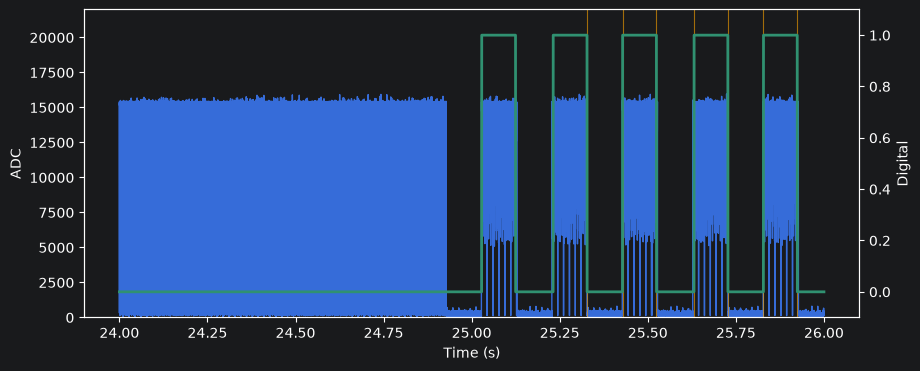

array([582843, 585896, 588813, 592045, 594956, 598015, 600926])

In [8]:
# start_time, end_time = 2792, 2796
# start_time, end_time = 696, 697

start_time, end_time = 24, 26


start_idx = np.searchsorted(ADC_continuous_time_stamp_data, start_time, side="left")
end_idx = np.searchsorted(ADC_continuous_time_stamp_data, end_time, side="right")

x = ADC_continuous_time_stamp_data[start_idx:end_idx]
y1 = photodiode_data[start_idx:end_idx]
y2 = ADC_DI_data_noGap[start_idx:end_idx]
edges_list = on_list_time

fig, ax1 = plt.subplots(figsize=(10, 4))

l1 = ax1.plot(x, y1, color='C0', lw=1, label='ADC')
ax1.set_ylim(0, 22000)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("ADC")

ax2 = ax1.twinx()
l2 = ax2.plot(x, y2, color='C3', lw=2, label='Digital')
ax2.set_ylim(-0.1, 1.1)
ax2.set_ylabel("Digital")

# Add on_list rising/falling edge markers inside this displayed time window.
# on_list_time is already in the same time base as x.
left = np.searchsorted(edges_list, x[0], side="left")
right = np.searchsorted(edges_list, x[-1], side="right")
visible_edges = edges_list[left:right]

visible_edge_indices = np.searchsorted(ADC_continuous_time_stamp_data, visible_edges)

for t in visible_edges:
    ax1.axvline(t, color="orange", lw=0.8, alpha=0.6)

plt.show()

visible_edge_indices

In [33]:
print(on_list_detected[6048:6050])

[18820570 18820577]


In [ ]:
np.save((npyfile_path := f"{base_dir}/data/on_list_times.npy"), on_list_idx_patched)


In [ ]:
len(on_list_idx_patched)

In [ ]:
a = on_list_time[1621]  # 47724427
b = on_list_time[1623]  # 47788633
n_insert = 14

normal_dt = np.median(np.diff(on_list_time))
n_interval = round((b - a) / normal_dt)
n_insert = n_interval - 1

inserted_t = np.linspace(a, b, n_insert + 2)[1:-1]

on_list_idx_patched = np.insert(on_list_time, 1622, inserted_t)

In [ ]:
base_dir = Path(base_dir)

continuous_dir = Path(continuous_folder)
recording_dir = continuous_dir.parent
events_dir = recording_dir / "events"

adc_stream = ADC_name.rstrip("/")

ADC_continuous_time_stamp_file = f'{continuous_folder}/{ADC_name}/timestamps.npy'
ADC_continuous_time_stamp_data_raw = np.load(ADC_continuous_time_stamp_file, mmap_mode='r')
ADC_continuous_time_stamp_data = ADC_continuous_time_stamp_data_raw  # - ADC_continuous_time_stamp_data_raw[0]
ADC_event_timestamp_raw = np.load(events_dir / adc_stream / "TTL" / "timestamps.npy", mmap_mode="r")
ADC_event_timestamp = ADC_event_timestamp_raw  # - ADC_continuous_time_stamp_data_raw[0]
if len(ADC_event_timestamp) < 2 or not np.all(np.diff(ADC_event_timestamp) > 0):
    raise ValueError("ADC TTL timestamps must contain at least two strictly increasing values.")

for probe in probe_list:
    probe = probe.upper()
    probe_stream = session_info[f"continuous_probe_{probe}_folder"].rstrip("/")

    probe_continuous_time_stamp_file = f'{continuous_folder}{probe_stream}/timestamps.npy'
    probe_continuous_time_stamp_data_raw = np.load(probe_continuous_time_stamp_file, mmap_mode='r')
    probe_continuous_time_stamp_data = probe_continuous_time_stamp_data_raw  # - probe_continuous_time_stamp_data_raw[0]

    probe_event_timestamp_raw = np.load(events_dir / probe_stream / "TTL" / "timestamps.npy", mmap_mode="r")
    probe_event_timestamp = probe_event_timestamp_raw  #- probe_continuous_time_stamp_data_raw[0]

    assert len(probe_event_timestamp) == len(ADC_event_timestamp), (
        f"Probe{probe} and ADC TTL counts differ: "
        f"{len(probe_event_timestamp)} vs {len(ADC_event_timestamp)}"
    )

    # probe_before_first_event = probe_continuous_time_stamp_data < probe_event_timestamp[0]
    # probe_after_last_event = probe_continuous_time_stamp_data > probe_event_timestamp[-1]
    # probe_spike_time = probe_continuous_time_stamp_data

    adc_probe_continuous_time_stamp_data = np.interp(
        probe_continuous_time_stamp_data,
        probe_event_timestamp,
        ADC_event_timestamp,
        left=0.0,
        right=float(ADC_continuous_time_stamp_data[-1]),
    )

    upscaled_adc_probe_continuous_time_stamp_data = np.interp(
        np.linspace(0,
                    len(adc_probe_continuous_time_stamp_data) - 1,
                    len(ADC_continuous_time_stamp_data), ),
        np.arange(len(adc_probe_continuous_time_stamp_data)),
        adc_probe_continuous_time_stamp_data,
    )

"""    probe_spike_time_all = np.load(f"{base_dir}/data/probe{probe}/probe_spike_time.npy")
    spike_before_first_event = probe_spike_time_all < probe_event_timestamp[0]
    spike_after_last_event = probe_spike_time_all > probe_event_timestamp[-1]
    probe_spike_time = probe_spike_time_all
    adc_spike_time = np.interp(
        probe_spike_time,
        probe_event_timestamp,
        ADC_event_timestamp,
        left=0.0,
        right=float(ADC_continuous_time_stamp_data[-1]),
    )

    assert len(adc_spike_time) == len(probe_spike_time)

    np.save(f"{base_dir}/data/probe{probe}/adc_spike_time.npy", adc_spike_time)
    print(
        f"Probe{probe}: kept all {len(adc_spike_time)} spikes; "
        f"set {spike_before_first_event.sum()} before the first TTL to 0 and "
        f"{spike_after_last_event.sum()} after the last TTL to the ADC continuous endpoint."
    )"""



In [ ]:
"""
Change all the variables below to match recording.
"""

is_overwrite_parameters: bool = True
base_dir = r"/mnt/senzailab/Kai/#Recording/m15"

# base_dir = "data"
date: str | int = "260706"

base_dir = f"{base_dir}/{date}"

# These are 0 indexed channel numbers
analogue_input_channel: int = 11

# Index of adc
recording_start_index: int = 0
recording_end_index: int = -1

time_interval: bool = False
is_signal_inverted: bool = True

detect_ADC_DI_threshold, fill_short_gaps_1, fill_short_gaps_2 = 15000, 10, 1000
detect_on_list_threshold: float = 0.5

parameters_file = Path(f'{base_dir}/data/parameters.json')

"""------------------------------------------------------------------"""

oebin_file_dir = next((Path(base_dir) / date).glob("*/experiment1/recording1/structure.oebin"))

session = Session(oebin_file_dir)
session_info = session.get_session_info()

base_data_dir = session_info['base_path']
record_nodes: str = session_info['record_nodes']
recording_name: str = session_info['recording_name']
experiment_id: str = session_info['experiment_id']

path_between = f'/{record_nodes}/{experiment_id}/'
continuous_folder = base_data_dir + path_between + recording_name + '/continuous/'

print("==============================")
print("Loading ADC npy data...")
ADC_name: str = session_info['continuous_ADC_folder']
analogue_total_input_channel_number: int = session_info['ADC_input_channel']
ADC_sampling_rate: float = session_info['ADC_sample_rate']
ADC_datafile = continuous_folder + ADC_name + '/continuous.dat'

photodiode_data = load_binary(ADC_datafile, analogue_total_input_channel_number, analogue_input_channel)[
    recording_start_index:recording_end_index]

ADC_continuous_time_stamp_file = f'{continuous_folder}/{ADC_name}/timestamps.npy'
ADC_continuous_time_stamp_data = ((ADC_continuous_time_stamp_data_raw := np.load(
    ADC_continuous_time_stamp_file, mmap_mode='r')) - ADC_continuous_time_stamp_data_raw[0])[
    recording_start_index:recording_end_index]

assert len(ADC_continuous_time_stamp_data) == len(
    photodiode_data), f"Length mismatch: {len(ADC_continuous_time_stamp_data)} vs {len(photodiode_data)}"

print(f"ADC_continuous_time_stamp_data: {ADC_continuous_time_stamp_data.shape}")
ADC_duration = len(photodiode_data) / ADC_sampling_rate
print(f"ADC duration: {ADC_duration} ")

ADC_DI_data_noGap = fill_short_gaps(~(fill_short_gaps(photodiode_data < 15000, min_gap=10)), min_gap=1000)

assert len(ADC_continuous_time_stamp_data) == len(
    ADC_DI_data_noGap), f"Length mismatch: {len(ADC_continuous_time_stamp_data)} vs {len(ADC_DI_data_noGap)}"

on_list_detected = detect_exposure_time(
    ADC_continuous_time_stamp_data,
    ADC_DI_data_noGap,
    threshold=detect_on_list_threshold,
    time_interval=False,
    is_inverted=is_signal_inverted,
    detection_target_label="on_list",
).ravel()

on_list_detected[-1] = (on_list_detected[-1] - 1) if on_list_detected[-1] == len(ADC_continuous_time_stamp_data) else \
    on_list_detected[-1]

on_list_time = ADC_continuous_time_stamp_data[on_list_detected]

#--------------
# manual  correction
# on_list_time = on_list_time[:-2]


np.save((npyfile_path := f"{base_dir}/data/on_list_times11.npy"), on_list_time)
print(f"on_list_time saved to {npyfile_path}")

In [ ]:
vs = np.load(f"{base_dir}/data/on_list_times11.npy")[1:]
photodiode = np.load(f"{base_dir}/data/on_list_times.npy")

In [ ]:
1000 * (vs - 11)[4:]

In [ ]:
1000 * (photodiode - 11)[4:]